In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()


In [3]:
data = pd.read_excel(r'C:\Users\TOSHIBA\Downloads\lgd_data.xlsx')

data.head()

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%
0,238203,729,36,3.81,47603,88,24,4,2,Rent,Home Improvement,Adjustable Rate,South,0.010000
1,170008,745,36,6.68,67474,71,43,4,2,Mortgage,Auto Loan,Adjustable Rate,South,0.757182
2,198937,681,24,8.38,77036,74,46,6,1,Own,Personal Loan,Fixed Rate,West,0.575147
3,262045,684,48,5.45,55083,85,24,0,0,Mortgage,Home Purchase,Adjustable Rate,West,0.009998
4,243378,758,72,6.64,70148,78,40,5,0,Mortgage,Debt Consolidation,Fixed Rate,North,1.000000


In [4]:
data.describe(include='all')

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%
count,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000,40000,40000,40000,40000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,2,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rent,Auto Loan,Adjustable Rate,North,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13420,8163,20161,10165,NaN
mean,149811.070400,700.667300,47.91060,6.499560,60069.306750,79.982225,30.08045,5.002275,0.998925,NaN,NaN,NaN,NaN,0.320288
std,49836.964295,49.974161,17.00847,1.504729,19926.497499,9.986641,9.98215,2.015557,0.818530,NaN,NaN,NaN,NaN,0.341183
min,-82998.000000,505.000000,24.00000,0.380000,-17513.000000,37.000000,-13.00000,-5.000000,0.000000,NaN,NaN,NaN,NaN,0.009717
25%,116398.000000,667.000000,36.00000,5.480000,46567.500000,73.000000,23.00000,4.000000,0.000000,NaN,NaN,NaN,NaN,0.010001
50%,149822.500000,701.000000,48.00000,6.490000,60058.000000,80.000000,30.00000,5.000000,1.000000,NaN,NaN,NaN,NaN,0.197368
75%,183328.000000,734.000000,60.00000,7.520000,73416.750000,87.000000,37.00000,6.000000,2.000000,NaN,NaN,NaN,NaN,0.572629


In [5]:
data.isnull().sum()

Exposure Amount ($)           0
Credit Score                  0
Loan Term (Months)            0
Interest Rate (%)             0
Income ($)                    0
Loan to Value Ratio (%)       0
Debt to Income Ratio (%)      0
Employment History (Years)    0
Previous Defaults             0
Home Ownership                0
Loan Purpose                  0
Loan Type                     0
Region                        0
LGD%                          0
dtype: int64

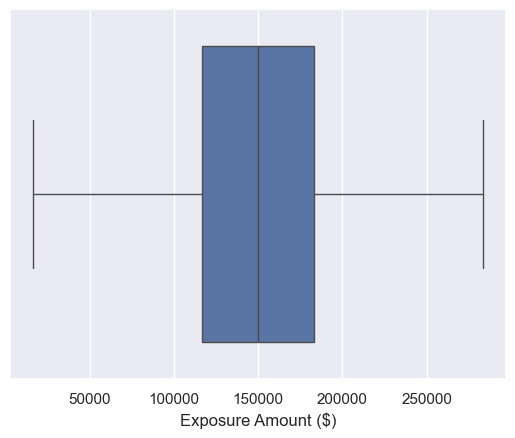

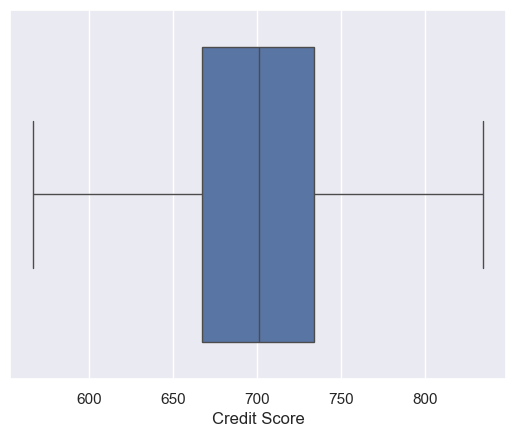

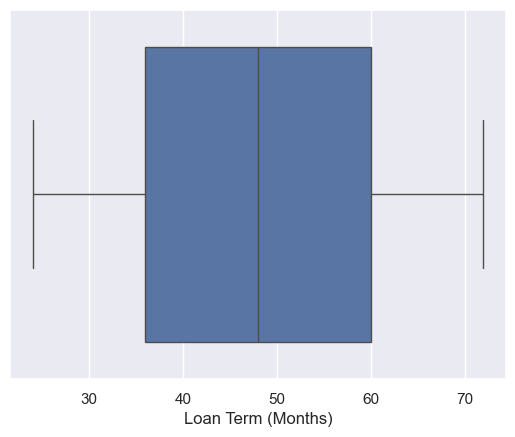

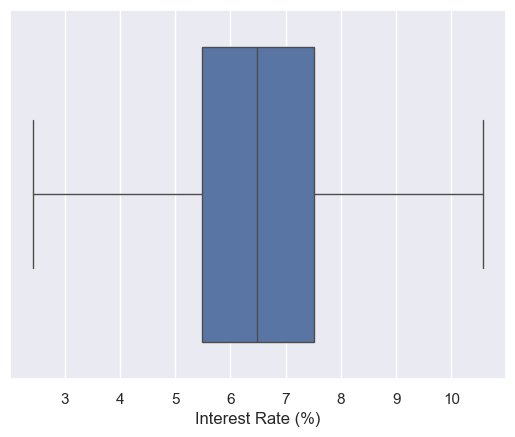

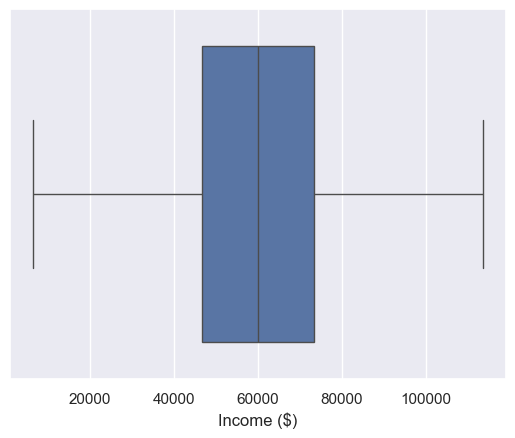

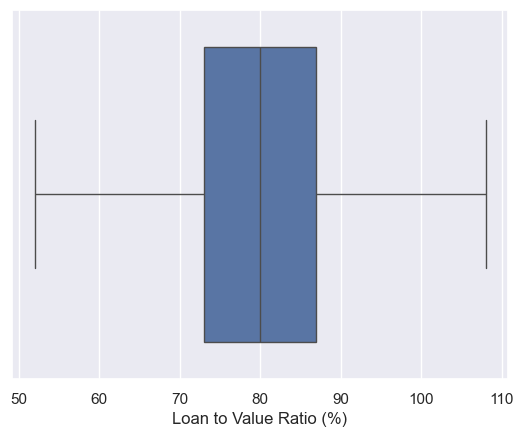

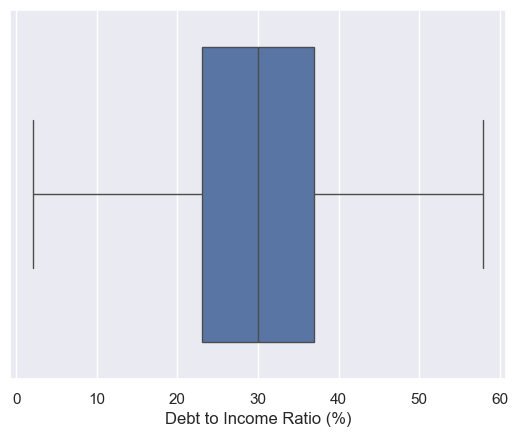

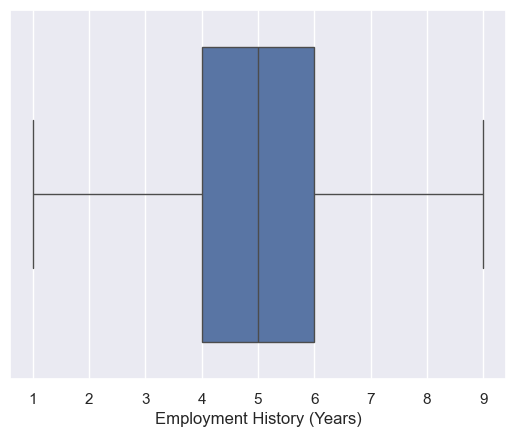

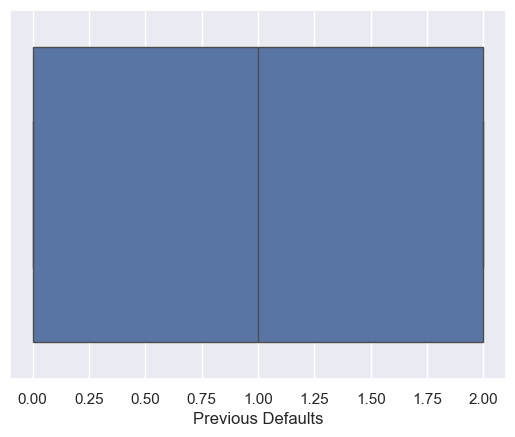

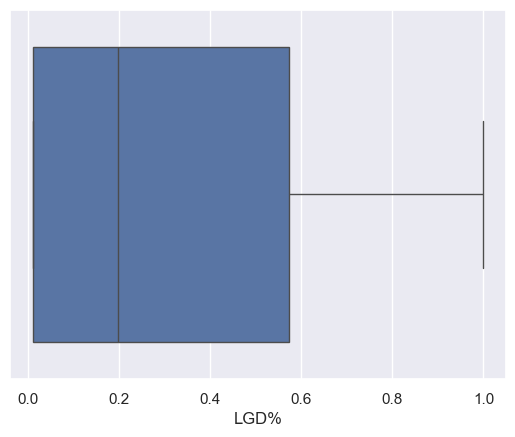

In [11]:
for i in data.columns:
    if data[i].dtypes!='str':
        sns.boxplot(data=data,x=data[i])
        plt.show()


In [12]:
q1=data.quantile(0.25, numeric_only=True)
q3=data.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

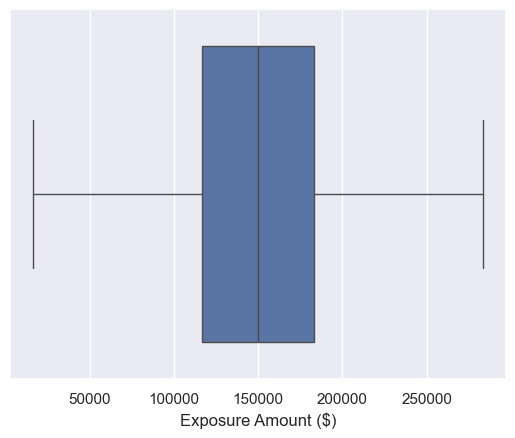

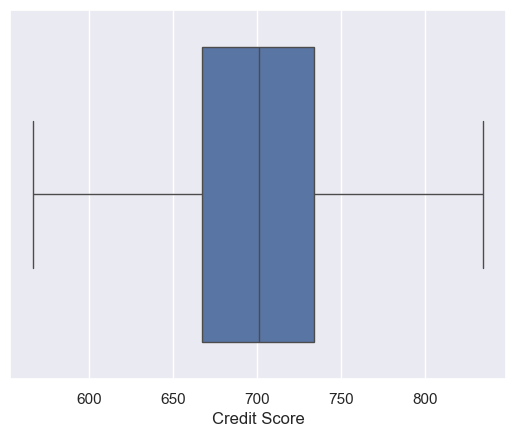

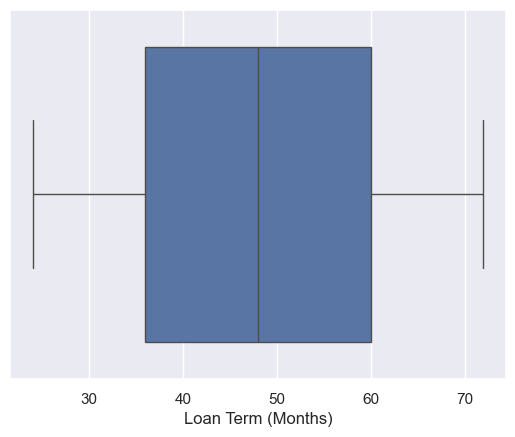

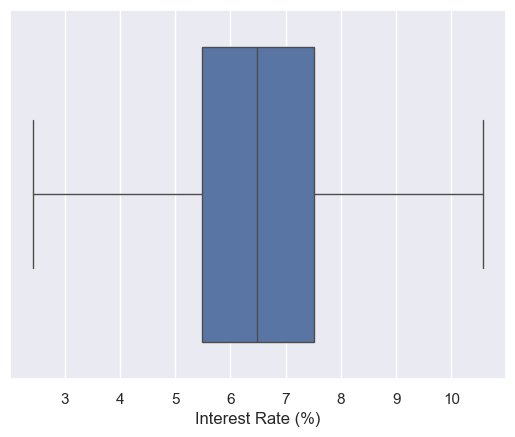

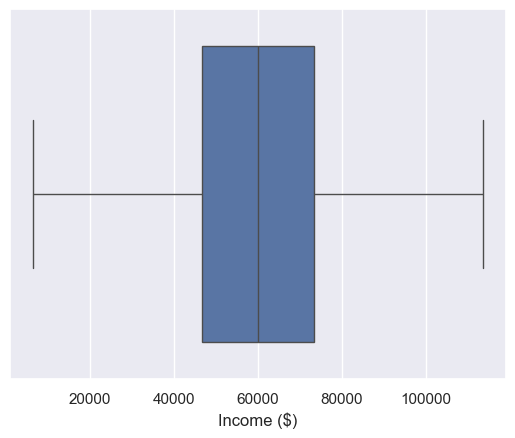

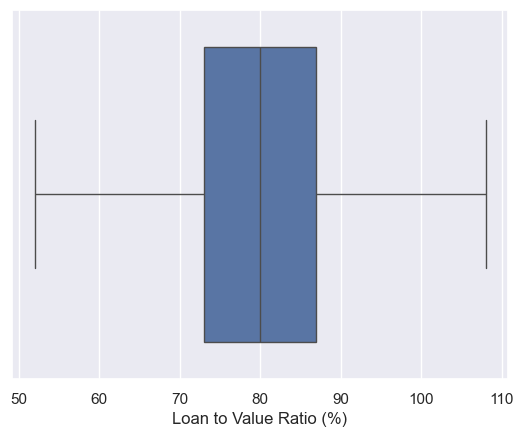

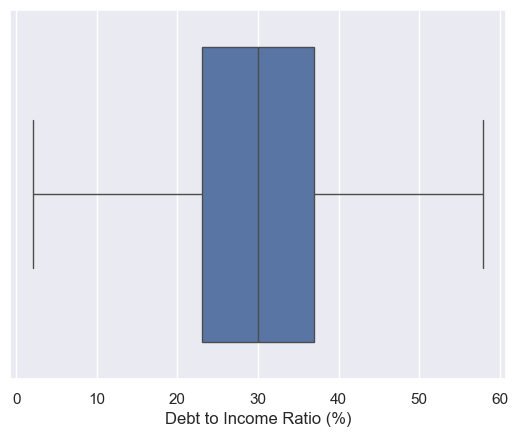

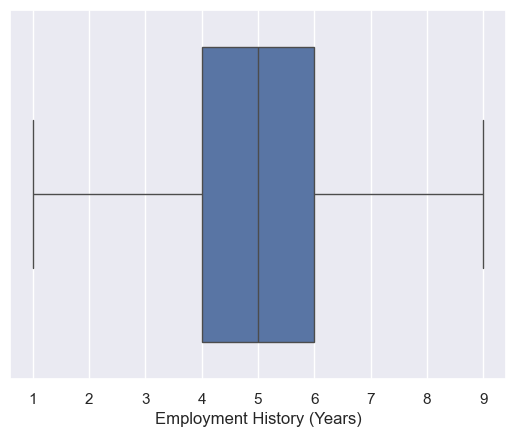

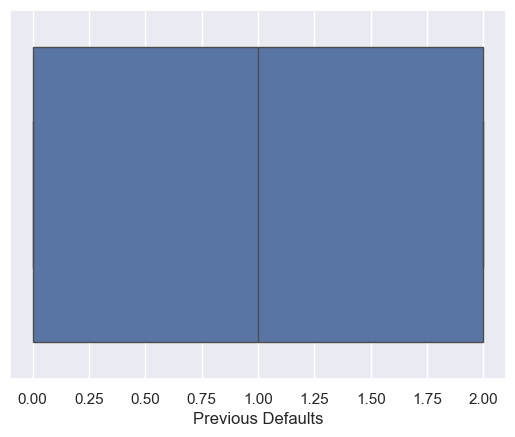

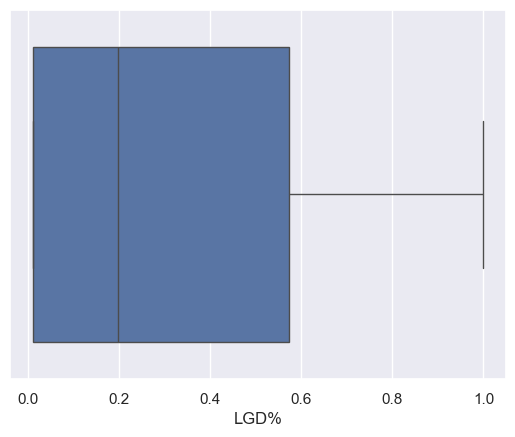

In [13]:
for i in data.columns:
    if data[i].dtypes!='str':
        data[i] = np.where(data[i] > Upper[i],Upper[i],data[i])
        data[i] = np.where(data[i] < Lower[i],Lower[i],data[i])
        sns.boxplot(data=data,x=data[i])
        plt.show()

In [14]:
data.columns

Index(['Exposure Amount ($)', 'Credit Score', 'Loan Term (Months)',
       'Interest Rate (%)', 'Income ($)', 'Loan to Value Ratio (%)',
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'Home Ownership', 'Loan Purpose', 'Loan Type',
       'Region', 'LGD%'],
      dtype='str')

In [15]:
data["Defaults_mean_by_Credit_Score"] = data.groupby("Credit Score")["Previous Defaults"].transform("mean")
data["Income_mean_by_Region"]  = data.groupby("Region")["Income ($)"].transform("mean")

data

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%,Defaults_mean_by_Credit_Score,Income_mean_by_Region
0,238203.0,729.0,36.0,3.81,47603.0,88.0,24.0,4.0,2.0,Rent,Home Improvement,Adjustable Rate,South,0.010000,0.938525,60082.674340
1,170008.0,745.0,36.0,6.68,67474.0,71.0,43.0,4.0,2.0,Mortgage,Auto Loan,Adjustable Rate,South,0.757182,1.022321,60082.674340
2,198937.0,681.0,24.0,8.38,77036.0,74.0,46.0,6.0,1.0,Own,Personal Loan,Fixed Rate,West,0.575147,1.030303,60307.337702
3,262045.0,684.0,48.0,5.45,55083.0,85.0,24.0,1.0,0.0,Mortgage,Home Purchase,Adjustable Rate,West,0.009998,0.985866,60307.337702
4,243378.0,758.0,72.0,6.64,70148.0,78.0,40.0,5.0,0.0,Mortgage,Debt Consolidation,Fixed Rate,North,1.000000,1.046512,59985.178837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,77140.0,723.0,24.0,5.62,71515.0,91.0,17.0,3.0,0.0,Mortgage,Debt Consolidation,Adjustable Rate,North,0.009995,0.986395,59985.178837
39996,250556.0,777.0,72.0,6.16,45326.0,88.0,34.0,3.0,0.0,Rent,Auto Loan,Fixed Rate,West,0.834943,1.033333,60307.337702
39997,234493.0,827.0,60.0,5.97,48418.0,78.0,24.0,7.0,1.0,Rent,Debt Consolidation,Fixed Rate,West,0.897571,1.000000,60307.337702
39998,159998.0,698.0,36.0,8.65,85987.0,73.0,37.0,6.0,0.0,Mortgage,Personal Loan,Adjustable Rate,West,0.445537,0.963087,60307.337702


In [18]:
from scipy import stats


for i in data.columns:
    
    if data[i].dtype in ['int64', 'float64']:
        
        kstest_statistic, kstest_p_value = stats.kstest(data[i], 'norm')
                
        print(f'Column: {i}')
        print(f'Kolmogorov-Smirnov Test:')
        print(f'Test Statistic: {kstest_statistic}')
        print(f'p-value: {kstest_p_value}')
        
        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

Column: Exposure Amount ($)
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: Credit Score
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: Loan Term (Months)
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: Interest Rate (%)
Kolmogorov-Smirnov Test:
Test Statistic: 0.9922397464494463
p-value: 0.0
Data does not look normally distributed

Column: Income ($)
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: Loan to Value Ratio (%)
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: Debt to Income Ratio (%)
Kolmogorov-Smirnov Test:
Test Statistic: 0.9957433287581668
p-value: 0.0
Data does not look normally distributed

Column: Employment History (Years)
Kolmogorov-Smirnov Test:
Test Statistic: 0.9380498680518

In [19]:
def target_correlation(data, target, threshold=0.1):
    
    corr = data.corr(numeric_only=True, method='spearman')[target].drop(target)
    
    corr = corr[corr.abs() >= threshold]
    
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
    
    return corr.reset_index().rename(
        columns={"index": "Variable", target: "Correlation with Target"})


target_result = target_correlation(data, 'LGD%')

target_result

,Variable,Correlation with Target
0,Credit Score,0.489755
1,Income ($),0.405091
2,Loan Term (Months),0.337089
3,Debt to Income Ratio (%),0.319163
4,Previous Defaults,0.253319
5,Loan to Value Ratio (%),0.240004
6,Interest Rate (%),0.165559
7,Employment History (Years),0.160256
8,Exposure Amount ($),0.108719


In [20]:
def intercorrelation(data, target, threshold=0.6):
    
    corr_matrix = data.drop(columns=[target]).corr(numeric_only=True, method='spearman')
    
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    high_corr = corr_matrix.where(mask).stack().reset_index()
    
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    
    return high_corr.reset_index(drop=True)



intercorrelated_result = intercorrelation(data, 'LGD%')
intercorrelated_result


,Variable 1,Variable 2,Correlation


In [21]:
target_result.Variable.tolist()

['Credit Score',
 'Income ($)',
 'Loan Term (Months)',
 'Debt to Income Ratio (%)',
 'Previous Defaults',
 'Loan to Value Ratio (%)',
 'Interest Rate (%)',
 'Employment History (Years)',
 'Exposure Amount ($)']

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data, variables):
    vif_data = data[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data, [ 
                                        'Exposure Amount ($)',
 #'Credit Score',
 'Loan Term (Months)',
 #'Interest Rate (%)',
 'Income ($)',
 #'Loan to Value Ratio (%)',
 'Debt to Income Ratio (%)',
 'Employment History (Years)',
 'Previous Defaults'
                                        ])

vif_result


,VIF,Features
0,8.070681,Exposure Amount ($)
1,7.324425,Loan Term (Months)
2,8.120835,Income ($)
3,8.116730,Debt to Income Ratio (%)
4,6.504986,Employment History (Years)
5,2.405987,Previous Defaults


In [23]:
data.dtypes

Exposure Amount ($)              float64
Credit Score                     float64
Loan Term (Months)               float64
Interest Rate (%)                float64
Income ($)                       float64
Loan to Value Ratio (%)          float64
Debt to Income Ratio (%)         float64
Employment History (Years)       float64
Previous Defaults                float64
Home Ownership                       str
Loan Purpose                         str
Loan Type                            str
Region                               str
LGD%                             float64
Defaults_mean_by_Credit_Score    float64
Income_mean_by_Region            float64
dtype: object

In [24]:
data.columns

Index(['Exposure Amount ($)', 'Credit Score', 'Loan Term (Months)',
       'Interest Rate (%)', 'Income ($)', 'Loan to Value Ratio (%)',
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'Home Ownership', 'Loan Purpose', 'Loan Type',
       'Region', 'LGD%', 'Defaults_mean_by_Credit_Score',
       'Income_mean_by_Region'],
      dtype='str')

In [25]:
data=data[['Exposure Amount ($)', 'Loan Term (Months)',
       'Income ($)', 
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'Home Ownership', 'Loan Purpose', 'Loan Type',
       'Region', 'Defaults_mean_by_Credit_Score',
       'Income_mean_by_Region','LGD%']]

In [26]:
data

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,Defaults_mean_by_Credit_Score,Income_mean_by_Region,LGD%
0,238203.0,36.0,47603.0,24.0,4.0,2.0,Rent,Home Improvement,Adjustable Rate,South,0.938525,60082.674340,0.010000
1,170008.0,36.0,67474.0,43.0,4.0,2.0,Mortgage,Auto Loan,Adjustable Rate,South,1.022321,60082.674340,0.757182
2,198937.0,24.0,77036.0,46.0,6.0,1.0,Own,Personal Loan,Fixed Rate,West,1.030303,60307.337702,0.575147
3,262045.0,48.0,55083.0,24.0,1.0,0.0,Mortgage,Home Purchase,Adjustable Rate,West,0.985866,60307.337702,0.009998
4,243378.0,72.0,70148.0,40.0,5.0,0.0,Mortgage,Debt Consolidation,Fixed Rate,North,1.046512,59985.178837,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,77140.0,24.0,71515.0,17.0,3.0,0.0,Mortgage,Debt Consolidation,Adjustable Rate,North,0.986395,59985.178837,0.009995
39996,250556.0,72.0,45326.0,34.0,3.0,0.0,Rent,Auto Loan,Fixed Rate,West,1.033333,60307.337702,0.834943
39997,234493.0,60.0,48418.0,24.0,7.0,1.0,Rent,Debt Consolidation,Fixed Rate,West,1.000000,60307.337702,0.897571
39998,159998.0,36.0,85987.0,37.0,6.0,0.0,Mortgage,Personal Loan,Adjustable Rate,West,0.963087,60307.337702,0.445537


In [27]:
data_dummies = pd.get_dummies(data, drop_first=True, dtype=int)

In [28]:
targets = data_dummies['LGD%']
inputs = data_dummies.drop(['LGD%'],axis=1)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(inputs)

inputs_scaled = scaler.transform(inputs)

data_scaled = pd.DataFrame(inputs_scaled, columns=inputs.columns)

data_scaled

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Defaults_mean_by_Credit_Score,Income_mean_by_Region,Home Ownership_Own,Home Ownership_Rent,Loan Purpose_Debt Consolidation,Loan Purpose_Home Improvement,Loan Purpose_Home Purchase,Loan Purpose_Personal Loan,Loan Type_Fixed Rate,Region_North,Region_South,Region_West
0,1.786404,-0.700283,-0.629277,-0.612479,-0.517597,1.223032,-0.869497,0.097178,-0.709601,1.407347,-0.501484,1.988973,-0.493154,-0.496208,-0.991982,-0.583701,1.736798,-0.578274
1,0.408114,-0.700283,0.373902,1.300527,-0.517597,1.223032,0.336804,0.097178,-0.709601,-0.710557,-0.501484,-0.502772,-0.493154,-0.496208,-0.991982,-0.583701,1.736798,-0.578274
2,0.992798,-1.405823,0.856635,1.602580,0.513114,0.001313,0.451704,1.559518,1.409243,-0.710557,-0.501484,-0.502772,-0.493154,2.015284,1.008083,-0.583701,-0.575772,1.729284
3,2.268275,0.005256,-0.251653,-0.612479,-2.063665,-1.220405,-0.187995,1.559518,-0.709601,-0.710557,-0.501484,-0.502772,2.027763,-0.496208,-0.991982,-0.583701,-0.575772,1.729284
4,1.890996,1.416336,0.508897,0.998473,-0.002242,-1.220405,0.685036,-0.537423,-0.709601,-0.710557,1.994082,-0.502772,-0.493154,-0.496208,1.008083,1.713205,-0.575772,-0.578274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-1.468843,-1.405823,0.577910,-1.317271,-1.032953,-1.220405,-0.180383,-0.537423,-0.709601,-0.710557,1.994082,-0.502772,-0.493154,-0.496208,-0.991982,1.713205,-0.575772,-0.578274
39996,2.036071,1.416336,-0.744231,0.394366,-1.032953,-1.220405,0.495327,1.559518,-0.709601,1.407347,-0.501484,-0.502772,-0.493154,-0.496208,1.008083,-0.583701,-0.575772,1.729284
39997,1.711421,0.710796,-0.588132,-0.612479,1.028470,0.001313,0.015475,1.559518,-0.709601,1.407347,1.994082,-0.502772,-0.493154,-0.496208,1.008083,-0.583701,-0.575772,1.729284
39998,0.205801,-0.700283,1.308522,0.696420,0.513114,-1.220405,-0.515904,1.559518,-0.709601,-0.710557,-0.501484,-0.502772,-0.493154,2.015284,-0.991982,-0.583701,-0.575772,1.729284


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_scaled, targets, test_size=0.2, random_state=42)

In [31]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred = reg.predict(X_test)

In [33]:
import pandas as pd
from sklearn import metrics
pd.options.display.float_format = '{:.2f}'.format


# Calculate metrics for the testing set
mae_test = metrics.mean_absolute_error(y_test, y_pred)
mse_test = metrics.mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = metrics.r2_score(y_test, y_pred)




# Calculate metrics for the training set
y_pred_train = reg.predict(X_train)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = metrics.r2_score(y_train, y_pred_train)




# Create a DataFrame to store the results
results_dict = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Train': [mae_train, mse_train, rmse_train, r2_train],
    'Test': [mae_test, mse_test, rmse_test, r2_test]
}

results_df = pd.DataFrame(results_dict)

results_df


,Metric,Train,Test
0,MAE,0.20,0.20
1,MSE,0.06,0.06
2,RMSE,0.24,0.25
3,R2,0.49,0.48


In [34]:
variables = []
train_r2_scores = []
test_r2_scores = []

for i in X_train.columns: 
    X_train_single_var = X_train[[i]]
    X_test_single_var = X_test[[i]]

    # Fit a regression model using the single variable on the training set
    reg.fit(X_train_single_var, y_train)
    y_pred_train_single_var = reg.predict(X_train_single_var)

    # Calculate R2 for the single variable model on the training set
    train_r2 = metrics.r2_score(y_train, y_pred_train_single_var)

    # Fit a regression model using the single variable on the test set
    reg.fit(X_test_single_var, y_test)
    y_pred_test_single_var = reg.predict(X_test_single_var)

    # Calculate R2 for the single variable model on the test set
    test_r2 = metrics.r2_score(y_test, y_pred_test_single_var)

    # Append the results to the lists
    variables.append(i)
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

# Create a DataFrame from the results

results_df = pd.DataFrame({'Variable': variables, 'Train R2': train_r2_scores, 'Test R2': test_r2_scores})

results_df_sorted = results_df.sort_values(by='Test R2', ascending=False)

pd.options.display.float_format = '{:.4f}'.format

results_df_sorted


,Variable,Train R2,Test R2
2,Income ($),0.1731,0.1603
1,Loan Term (Months),0.1101,0.1134
3,Debt to Income Ratio (%),0.1082,0.1021
5,Previous Defaults,0.0635,0.0649
4,Employment History (Years),0.0256,0.0319
0,Exposure Amount ($),0.0133,0.0106
6,Defaults_mean_by_Credit_Score,0.0021,0.0023
15,Region_North,0.0001,0.0010
16,Region_South,0.0000,0.0007
17,Region_West,0.0000,0.0000


In [35]:
data_scaled.columns

Index(['Exposure Amount ($)', 'Loan Term (Months)', 'Income ($)',
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'Defaults_mean_by_Credit_Score',
       'Income_mean_by_Region', 'Home Ownership_Own', 'Home Ownership_Rent',
       'Loan Purpose_Debt Consolidation', 'Loan Purpose_Home Improvement',
       'Loan Purpose_Home Purchase', 'Loan Purpose_Personal Loan',
       'Loan Type_Fixed Rate', 'Region_North', 'Region_South', 'Region_West'],
      dtype='str')

In [36]:
#targets = data_dummies['lgd']

inputs = data_scaled[['Exposure Amount ($)', 'Income ($)','Debt to Income Ratio (%)', 
                      'Loan Term (Months)','Previous Defaults','Employment History (Years)']]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=42)

In [38]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = reg.predict(X_test)

In [40]:
# Calculate metrics for the testing set
mae_test = metrics.mean_absolute_error(y_test, y_pred)
mse_test = metrics.mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = metrics.r2_score(y_test, y_pred)

# Calculate metrics for the training set
y_pred_train = reg.predict(X_train)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = metrics.r2_score(y_train, y_pred_train)

# Create a DataFrame to store the results
results_dict = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Train': [mae_train, mse_train, rmse_train, r2_train],
    'Test': [mae_test, mse_test, rmse_test, r2_test]
}

results_df = pd.DataFrame(results_dict)

results_df


,Metric,Train,Test
0,MAE,0.1969,0.1987
1,MSE,0.0591,0.0601
2,RMSE,0.2432,0.2451
3,R2,0.4927,0.4809


# deployment

In [44]:
df1 = pd.read_excel(r'C:\Users\TOSHIBA\Downloads\lgd_data_deploy.xlsx')

df1

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region
0,153539,715,36,6.8500,57712,92,23,6,1,Mortgage,Home Improvement,Adjustable Rate,West
1,137842,713,36,6.6500,37490,83,41,7,0,Mortgage,Debt Consolidation,Fixed Rate,East
2,187289,606,72,5.0000,35857,79,46,7,1,Mortgage,Home Improvement,Adjustable Rate,East
3,98051,817,72,6.0100,37531,91,20,4,2,Mortgage,Home Improvement,Fixed Rate,East
4,120672,659,36,5.8800,84892,93,28,2,0,Rent,Debt Consolidation,Adjustable Rate,East
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,83740,610,24,5.3700,66358,69,23,4,1,Mortgage,Debt Consolidation,Adjustable Rate,South
396,129005,635,36,7.5100,71919,84,38,5,1,Own,Debt Consolidation,Adjustable Rate,South
397,129767,760,72,6.9300,28667,98,42,4,0,Rent,Debt Consolidation,Adjustable Rate,West
398,196097,695,24,4.1200,55885,69,38,5,0,Mortgage,Home Purchase,Adjustable Rate,West


In [45]:
df1["Defaults_mean_by_Credit_Score"] = df1.groupby("Credit Score")["Previous Defaults"].transform("mean")
df1["Income_mean_by_Region"]  = df1.groupby("Region")["Income ($)"].transform("mean")

df1

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,Defaults_mean_by_Credit_Score,Income_mean_by_Region
0,153539,715,36,6.8500,57712,92,23,6,1,Mortgage,Home Improvement,Adjustable Rate,West,0.2500,60445.3762
1,137842,713,36,6.6500,37490,83,41,7,0,Mortgage,Debt Consolidation,Fixed Rate,East,0.6667,59553.8539
2,187289,606,72,5.0000,35857,79,46,7,1,Mortgage,Home Improvement,Adjustable Rate,East,1.0000,59553.8539
3,98051,817,72,6.0100,37531,91,20,4,2,Mortgage,Home Improvement,Fixed Rate,East,2.0000,59553.8539
4,120672,659,36,5.8800,84892,93,28,2,0,Rent,Debt Consolidation,Adjustable Rate,East,0.0000,59553.8539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,83740,610,24,5.3700,66358,69,23,4,1,Mortgage,Debt Consolidation,Adjustable Rate,South,0.5000,59857.0182
396,129005,635,36,7.5100,71919,84,38,5,1,Own,Debt Consolidation,Adjustable Rate,South,1.3333,59857.0182
397,129767,760,72,6.9300,28667,98,42,4,0,Rent,Debt Consolidation,Adjustable Rate,West,0.0000,60445.3762
398,196097,695,24,4.1200,55885,69,38,5,0,Mortgage,Home Purchase,Adjustable Rate,West,0.0000,60445.3762


In [46]:
df1 = pd.get_dummies(df1, dtype=int)

In [47]:
data_dummies.columns

Index(['Exposure Amount ($)', 'Loan Term (Months)', 'Income ($)',
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'Defaults_mean_by_Credit_Score',
       'Income_mean_by_Region', 'LGD%', 'Home Ownership_Own',
       'Home Ownership_Rent', 'Loan Purpose_Debt Consolidation',
       'Loan Purpose_Home Improvement', 'Loan Purpose_Home Purchase',
       'Loan Purpose_Personal Loan', 'Loan Type_Fixed Rate', 'Region_North',
       'Region_South', 'Region_West'],
      dtype='str')

In [48]:
df1=df1[['Exposure Amount ($)', 'Loan Term (Months)', 'Income ($)',
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'Defaults_mean_by_Credit_Score',
       'Income_mean_by_Region', 'Home Ownership_Own',
       'Home Ownership_Rent', 'Loan Purpose_Debt Consolidation',
       'Loan Purpose_Home Improvement', 'Loan Purpose_Home Purchase',
       'Loan Purpose_Personal Loan', 'Loan Type_Fixed Rate', 'Region_North',
       'Region_South', 'Region_West']]

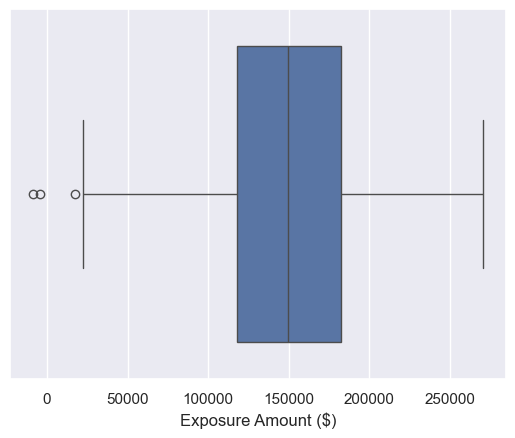

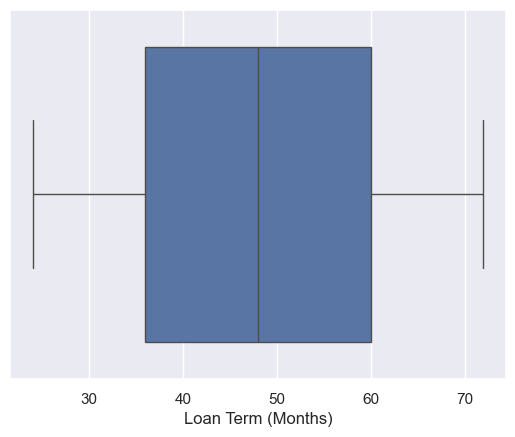

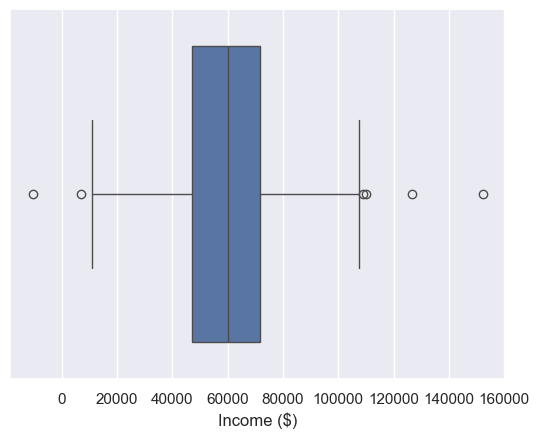

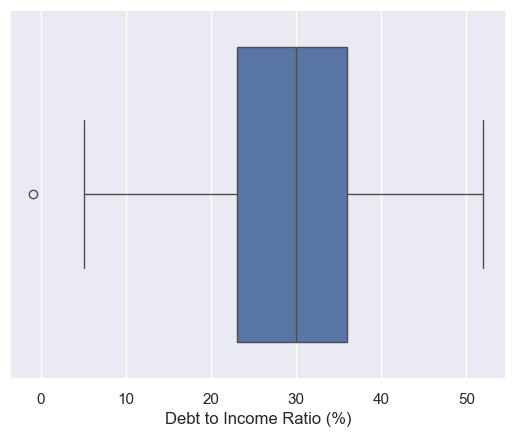

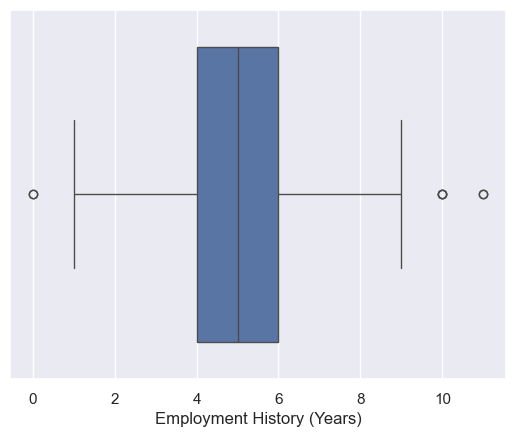

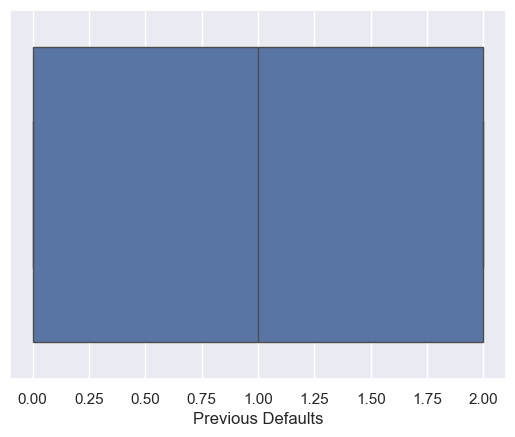

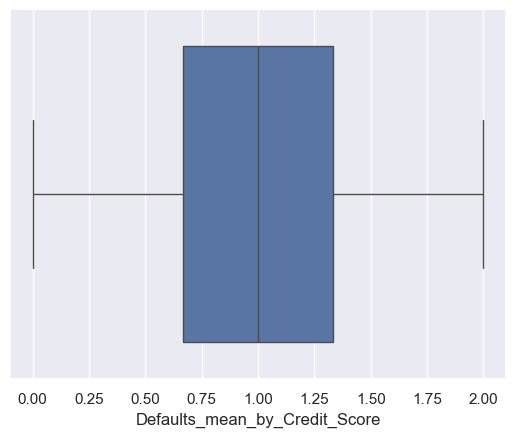

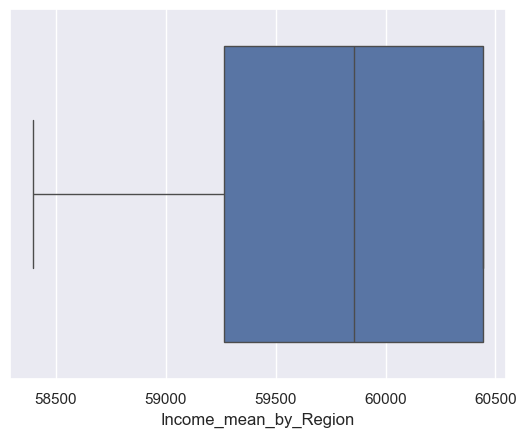

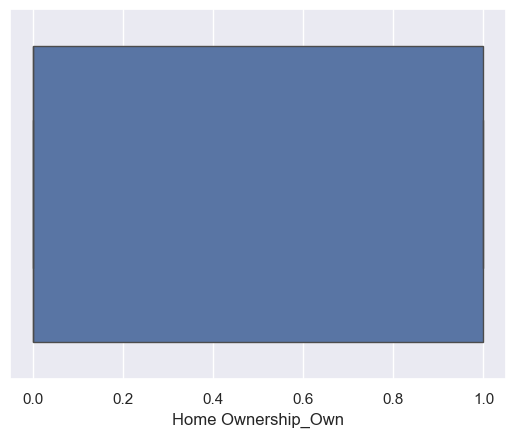

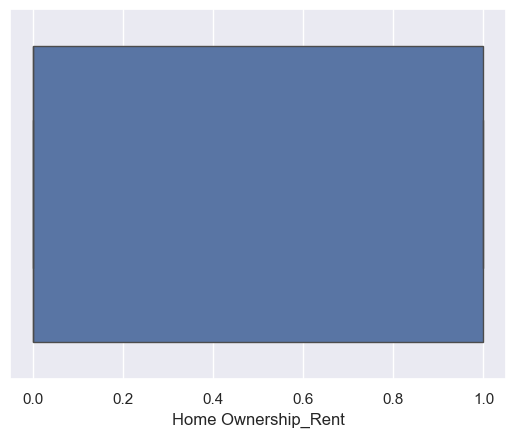

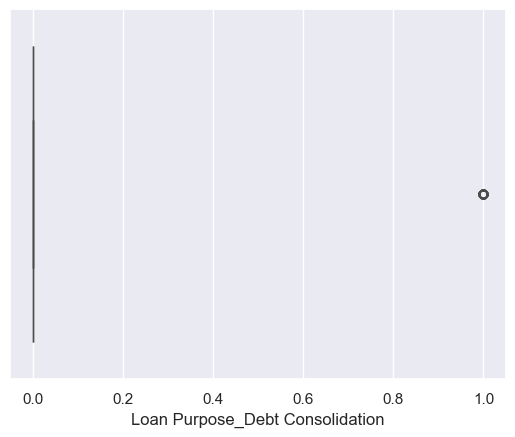

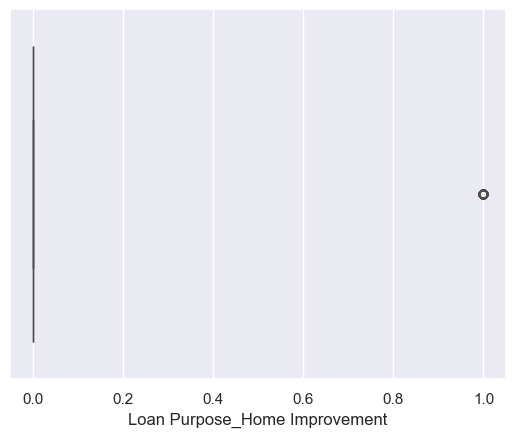

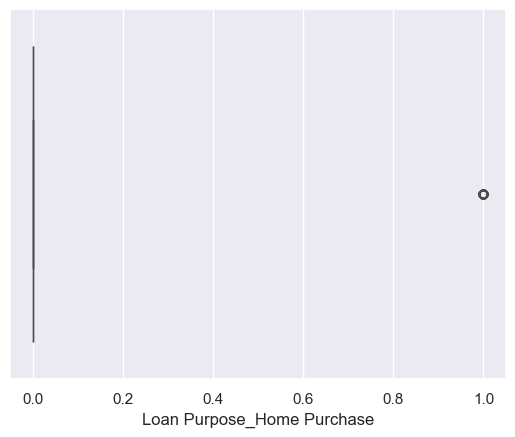

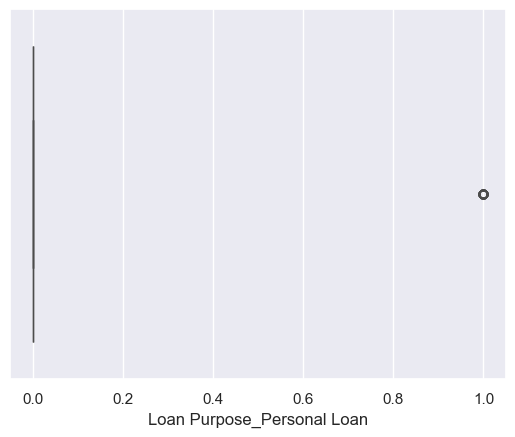

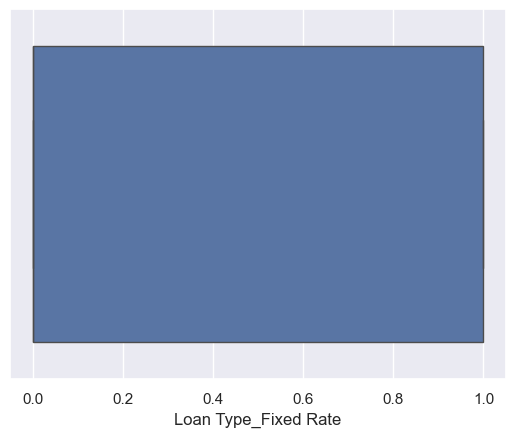

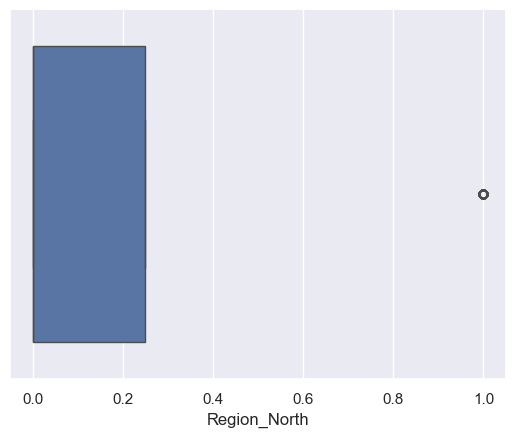

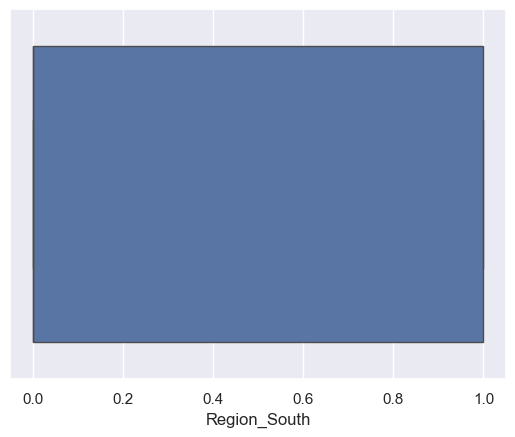

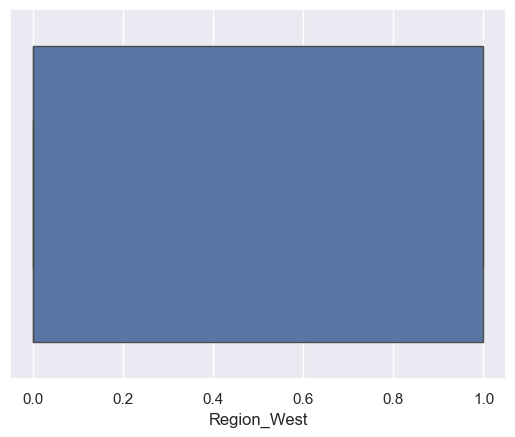

In [50]:
for i in df1.columns:
    if df1[i].dtype !='str':
        sns.boxplot(data=df1, x = i)
        plt.show()

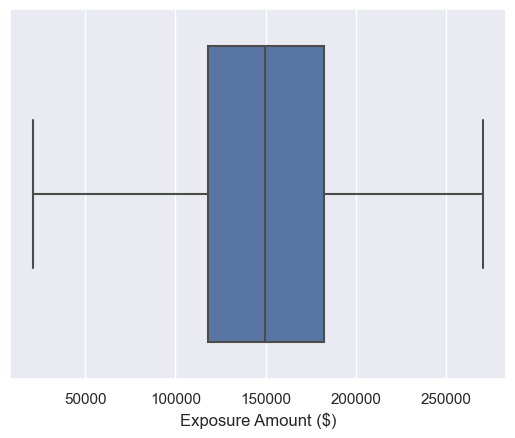

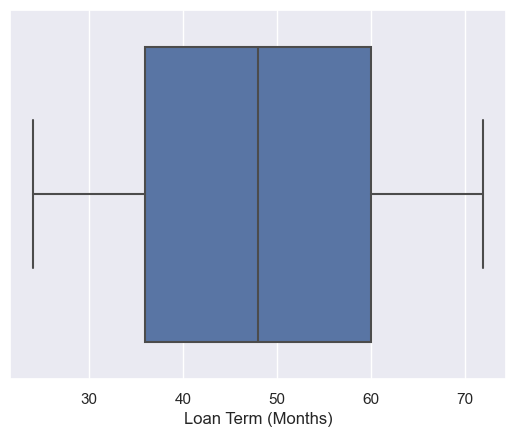

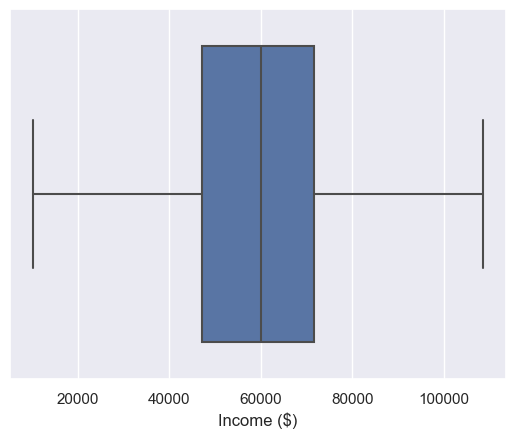

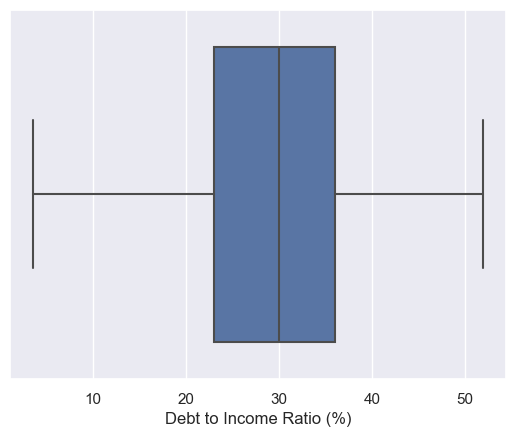

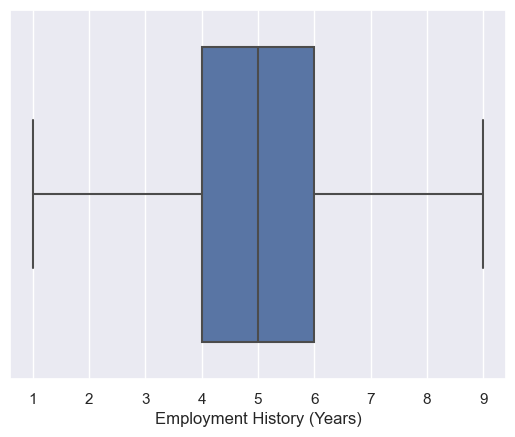

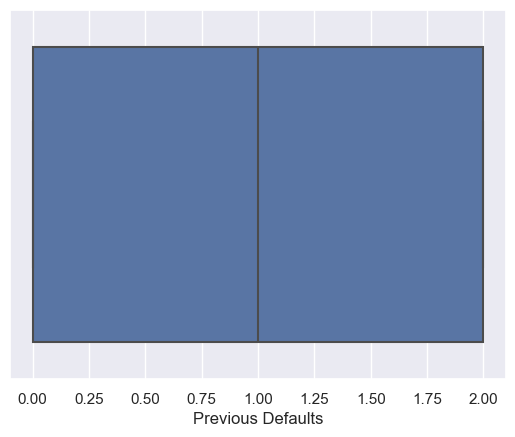

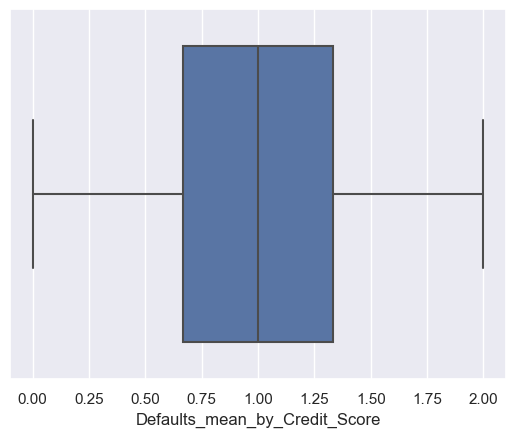

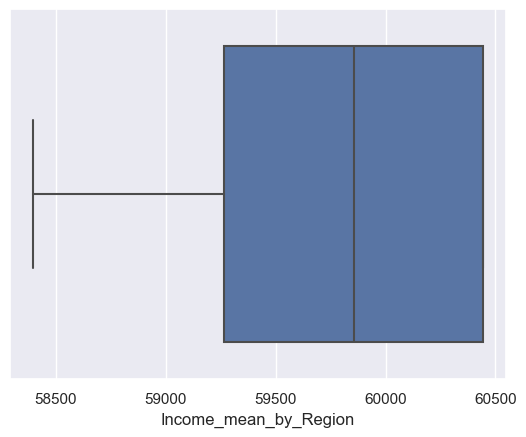

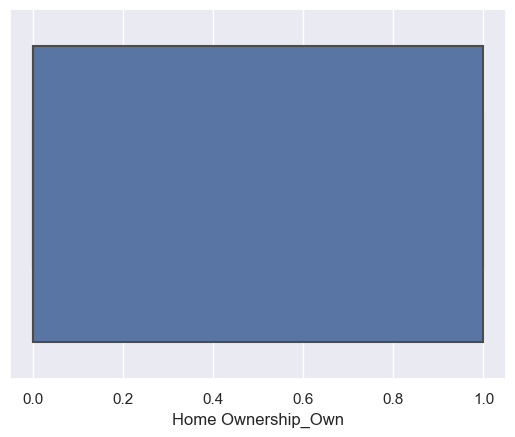

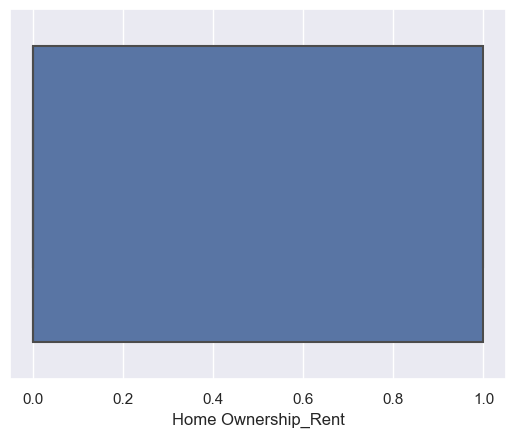

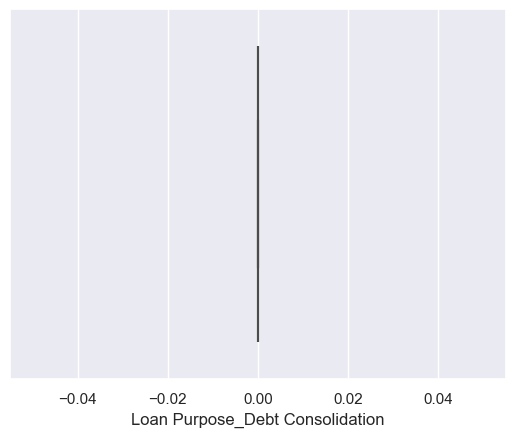

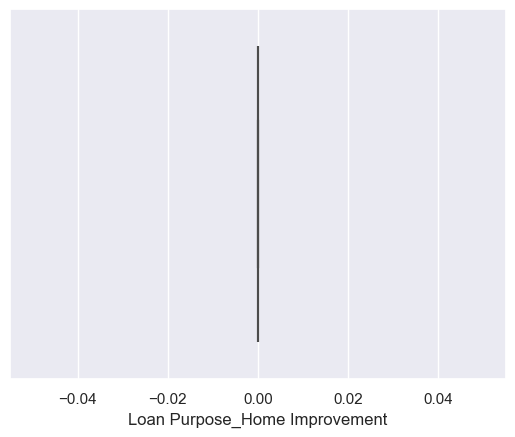

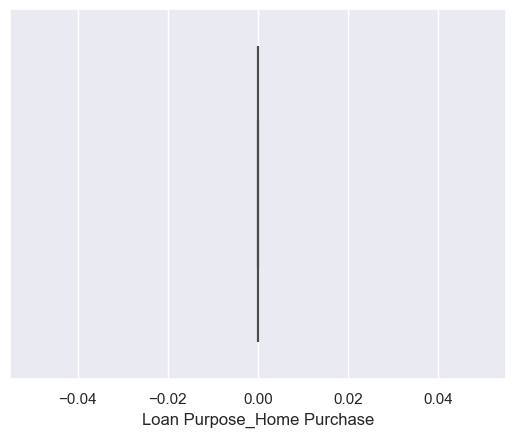

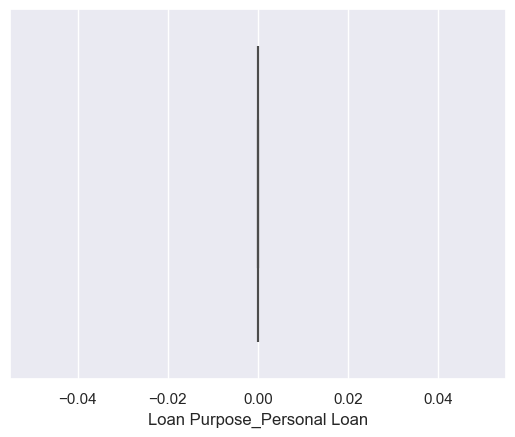

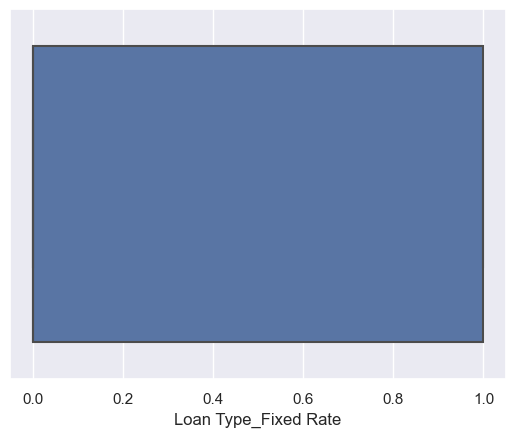

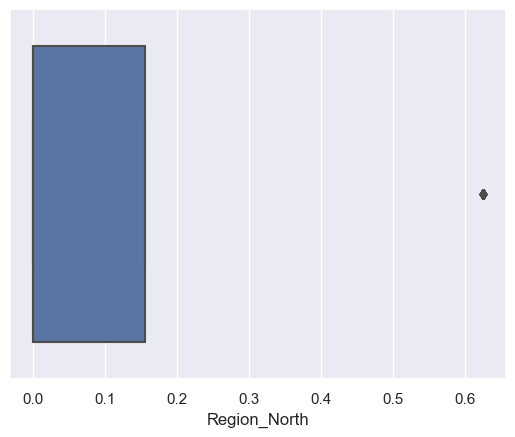

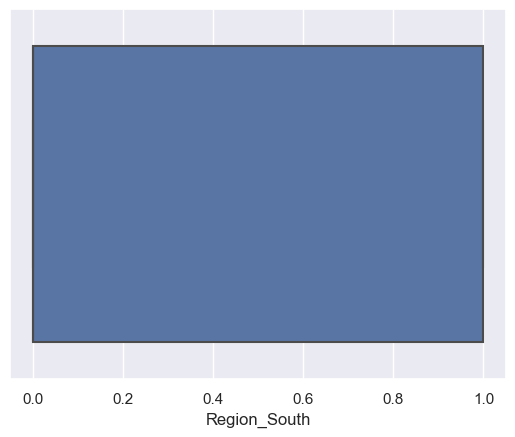

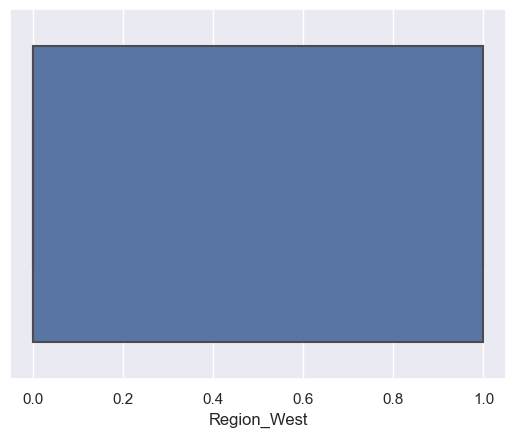

In [67]:
q1 = df1.quantile(0.25, numeric_only=True)
q3 = df1.quantile(0.75,numeric_only=True)
IQR = q3-q1
lower = q1-1.5*IQR
upper = q3+1.5*IQR

for i in df1.columns:
    if df1[i].dtypes!=obj:
        df1[i] = np.where(df1[i] > upper[i],upper[i],df1[i])
        df1[i] = np.where(df1[i] < lower[i],lower[i],df1[i])
        sns.boxplot(data=df1,x=i)
        plt.show()

In [68]:
inputs_deploy_scaled = scaler.transform(df1)

data_deploy_scaled = pd.DataFrame(inputs_deploy_scaled, columns=df1.columns)

data_deploy_scaled

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Defaults_mean_by_Credit_Score,Income_mean_by_Region,Home Ownership_Own,Home Ownership_Rent,Loan Purpose_Debt Consolidation,Loan Purpose_Home Improvement,Loan Purpose_Home Purchase,Loan Purpose_Personal Loan,Loan Type_Fixed Rate,Region_North,Region_South,Region_West
0,0.0753,-0.7003,-0.1189,-0.7132,0.5131,0.0013,-10.7812,2.4580,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,1.7293
1,-0.2420,-0.7003,-1.1398,1.0992,1.0285,-1.2204,-4.7830,-3.3449,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,1.0081,-0.5837,-0.5758,-0.5783
2,0.7574,1.4163,-1.2223,1.6026,1.0285,0.0013,0.0155,-3.3449,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,-0.5783
3,-1.0462,1.4163,-1.1378,-1.0152,-0.5176,1.2230,14.4110,-3.3449,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,1.0081,-0.5837,-0.5758,-0.5783
4,-0.5890,-0.7003,1.2532,-0.2097,-1.5483,-1.2204,-14.3801,-3.3449,-0.7096,1.4073,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,-0.5783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,-1.3355,-1.4058,0.3176,-0.7132,-0.5176,0.0013,-7.1823,-1.3716,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,1.7368,-0.5783
396,-0.4206,-0.7003,0.5983,0.7971,-0.0022,0.0013,4.8140,-1.3716,1.4092,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,1.7368,-0.5783
397,-0.4052,1.4163,-1.5853,1.1998,-0.5176,-1.2204,-14.3801,2.4580,-0.7096,1.4073,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,1.7293
398,0.9354,-1.4058,-0.2112,0.7971,-0.0022,-1.2204,-14.3801,2.4580,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,1.7293


In [69]:
inputs.columns

Index(['Exposure Amount ($)', 'Income ($)', 'Debt to Income Ratio (%)',
       'Loan Term (Months)', 'Previous Defaults',
       'Employment History (Years)'],
      dtype='object')

In [70]:
df_dep=data_deploy_scaled[['Exposure Amount ($)', 'Income ($)', 'Debt to Income Ratio (%)',
       'Loan Term (Months)', 'Previous Defaults',
       'Employment History (Years)']]

df_dep

,Exposure Amount ($),Income ($),Debt to Income Ratio (%),Loan Term (Months),Previous Defaults,Employment History (Years)
0,0.0753,-0.1189,-0.7132,-0.7003,0.0013,0.5131
1,-0.2420,-1.1398,1.0992,-0.7003,-1.2204,1.0285
2,0.7574,-1.2223,1.6026,1.4163,0.0013,1.0285
3,-1.0462,-1.1378,-1.0152,1.4163,1.2230,-0.5176
4,-0.5890,1.2532,-0.2097,-0.7003,-1.2204,-1.5483
...,...,...,...,...,...,...
395,-1.3355,0.3176,-0.7132,-1.4058,0.0013,-0.5176
396,-0.4206,0.5983,0.7971,-0.7003,0.0013,-0.0022
397,-0.4052,-1.5853,1.1998,1.4163,-1.2204,-0.5176
398,0.9354,-0.2112,0.7971,-1.4058,-1.2204,-0.0022


In [71]:
df_dep['predicted_lgd'] = reg.predict(df_dep)

df_dep

/var/folders/br/yvkmbr3121n8fd9q6wdmyqfm0000gp/T/ipykernel_38423/1265071577.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dep['predicted_lgd'] = reg.predict(df_dep)


,Exposure Amount ($),Income ($),Debt to Income Ratio (%),Loan Term (Months),Previous Defaults,Employment History (Years),predicted_lgd
0,0.0753,-0.1189,-0.7132,-0.7003,0.0013,0.5131,0.1764
1,-0.2420,-1.1398,1.0992,-0.7003,-1.2204,1.0285,0.1452
2,0.7574,-1.2223,1.6026,1.4163,0.0013,1.0285,0.5753
3,-1.0462,-1.1378,-1.0152,1.4163,1.2230,-0.5176,0.2453
4,-0.5890,1.2532,-0.2097,-0.7003,-1.2204,-1.5483,0.1792
...,...,...,...,...,...,...,...
395,-1.3355,0.3176,-0.7132,-1.4058,0.0013,-0.5176,0.0452
396,-0.4206,0.5983,0.7971,-0.7003,0.0013,-0.0022,0.3974
397,-0.4052,-1.5853,1.1998,1.4163,-1.2204,-0.5176,0.2424
398,0.9354,-0.2112,0.7971,-1.4058,-1.2204,-0.0022,0.1501
